Course: Diffuse and Stochastic Processes, Namiko Mitarai, NBI, University of Copenhagen

Assignment Part 1

Peter Resch, 2.6.2026

# Langevin simulation for a wed double well potential

# a) Propose a reaction scheme
should inlcude meaningful modification that change qualitative behaviour of system
briefly describe physical, biological,... motivation of model
write down equation, define vars and params
predict qualitative behaviour of mean and variance over time - increase, decrease, steady state
explain which terms could lead to this behaviour

In my simulation I am going to make a biased brownian motion in a double well potential $U(x)$. This could simulate cyclists riding along a road, which has some curvature - is the highest in the middle and falling off on both sides - so its not easy to always ride on the highest point. No one wants to cycle next to the road in the grass, so this is also accounted for with the repellent effect of the potential far off. There is also constant term, that could be seen as wind coming constantly from one side and pushing the cyclists towards one side.

The Langevin equation, which describes the position on the curvature of the street over time is
$\frac{dX}{dt}=X-\frac{1}{\eta} \frac{dU(X)}{dx}+ W + \Delta R  $,
where
$U(x)=\frac{1}{2} (x^{4} a-x^{2} b)$, therefore $\frac{dU}{dx}=2 x^{3} a-x b$ with $\langle\Delta R^{2}\rangle= 2 D \Delta t$ and $\langle R \rangle= 0 $

$\eta$ is the viscosity and could be interpreted in this model as the reactiveness of steering of the cyclist.
$\Delta R$ are the random deviations of steering during cycling.

My prediction without wind is, that over time the cyclists will rather be more in the valleys of the potential, sometimes switching sides, depending on how high the potential in the middle is or how strong the random term (the diffusion coefficient) is respectively. This means, that the mean should be zero and the variance reaches a steady state, as the potential gives boundaries to the diffusion.
With the wind though, in the long run the trajectories get pushed more to one side, through which the mean should also be pushed to one side. For me it is hard to make predictions on the variance on a general case in this model, as it could be lower or higher than in the case without wind, as $Var=\langle (X-\langle X \rangle)^2 \rangle$. As the deviation far away from the mean counts more, but might be also rare, the variance is depending on the parameter values of the potential and the wind bias, I suspect.

In [ ]:

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from tqdm import tqdm

r = np.random
r.seed(42)



#--------------------------------------------Functions--------------------------------------------
def brownian_movement(diffusion_coef, time_step):
    return np.random.normal(0, np.sqrt(2 * diffusion_coef * time_step))

def U(x,a,b):
    return 1/2*(x**4*a-x**2*b)

def wind(w):
    return w

def potential_force(x, a,b, eta):
    return -(1/eta)*(2*a * x**3 - b* x) 

def next_position(current_position, d,a,b,eta, t_step,w):
    return current_position +potential_force(current_position, a, b, eta)*t_step+ wind(w)* t_step + brownian_movement(d,t_step) 


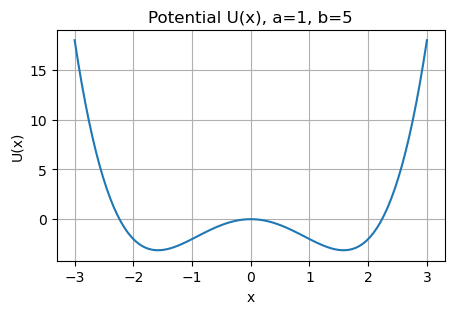

In [108]:
#plot potential force

x_array= np.linspace(-3, 3, 100)
U_array = U(x_array, 1, 5)
fig,ax= plt.subplots(1, figsize=(5,3))
ax.plot(x_array, U_array)
ax.set_title('Potential U(x), a=1, b=5')
ax.set_xlabel('x')
ax.set_ylabel('U(x)')
ax.grid()
fig.savefig('potential_force.png')

b) choose specific initial condition

simulate, using explicit implementation of stoch. integration method

simulate long enough to see interesting dynamics

plot 3 traj

In [109]:
#----------Initial parameters------
w=1.0
a=1.0
b=5.0
eta=2.0
d=2.0
initial_position = -2.0
time_step=0.1
total_time=40

num_simulations=1000


In [ ]:
t_step_array=[]
for i in range(4):
    t_step_array.append(time_step/(2**i))
t_step_array=np.array(t_step_array)

num_steps = (total_time / t_step_array).astype(int)
positions = []
time_array = []

for it,t_step in enumerate(t_step_array):
    positions.append(np.zeros(( num_simulations, num_steps[it])))
    positions[it][:, 0] = initial_position
    time_array.append(np.arange(0, total_time, t_step))

#print("Starting Simulation...")
for it,t_step in enumerate(t_step_array):
    print(f"Simulating for time step: {t_step} min")
    for i in range(num_simulations):
        print(f"\rSimulation {i+1}/{num_simulations}", end=' ')
        for j in range(1, num_steps[it]):
            positions[it][i, j] = next_position(positions[it][i, j-1], d,a,b,eta, t_step, w)
            
print("Simulation completed.")

Simulating for time step: 0.1 min
Simulation 69/1000 

Simulation 1000/1000 Simulating for time step: 0.05 min
Simulation 1000/1000 Simulating for time step: 0.025 min
Simulation 1000/1000 Simulating for time step: 0.0125 min
Simulation 1000/1000 Simulation completed.


In [ ]:
#simulate without wind
positions_no_wind = np.zeros(( num_simulations, num_steps[0]))
positions_no_wind[:, 0] = initial_position
for i in range(num_simulations):
    for j in range(1, num_steps[0]):
        positions_no_wind[i, j] = next_position(positions_no_wind[i, j-1], d,a,b,eta, t_step_array[0], 0.0)
print(f"t_step:", t_step_array[0], "min")

In [ ]:
#calculate mean and variance of positions without wind
mean_positions_no_wind = np.mean(positions_no_wind, axis=0)
var_positions_no_wind = np.var(positions_no_wind, axis=0)

t_step: 0.1 min


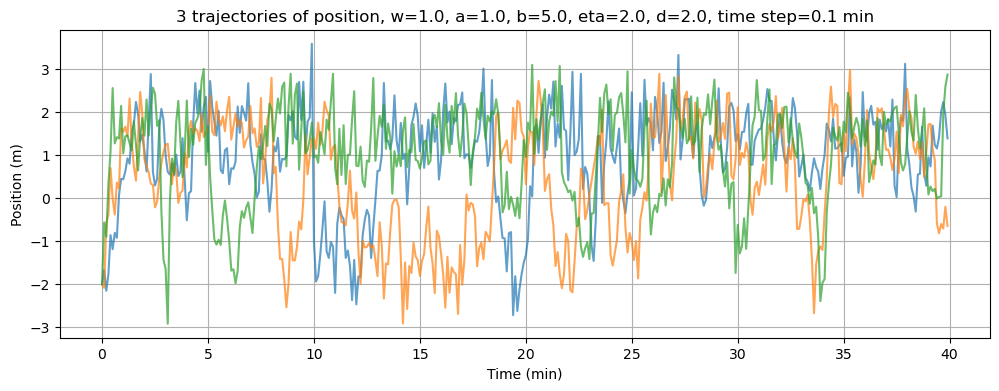

In [ ]:
#plot 3 trajectories for each time step
t_until=total_time
fig,ax=plt.subplots(figsize=(12, 4))
#for it,t_step in enumerate([t_step_array]):
it=0
until=int(t_until/t_step)
for i in range(3):
    ax.plot(time_array[it][:until], positions[it][i,:until], alpha=0.7)#c=plt.cm.plasma(it/3.5),
ax.set_title(f'3 trajectories of position, w={w}, a={a}, b={b}, eta={eta}, d={d}, time step={t_step_array[it]} min')
ax.set_xlabel('Time (min)')
ax.set_ylabel('Position (m)')
ax.grid()
#fig.savefig('3trajectories.png')

## Simulate 100 trajectories

c) plot
-ensemble averaged mean and 
-variance 
vs time

show that results are robust against halving of integration time step

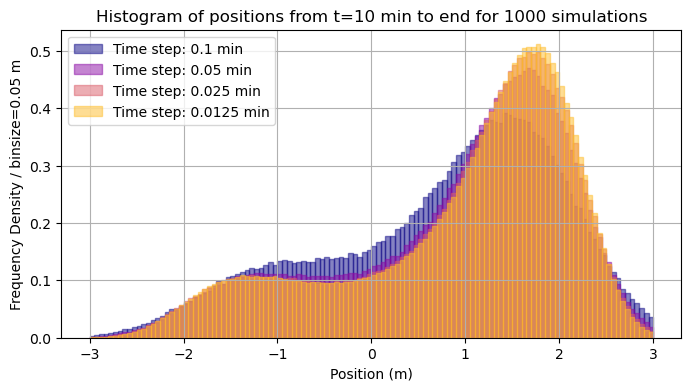

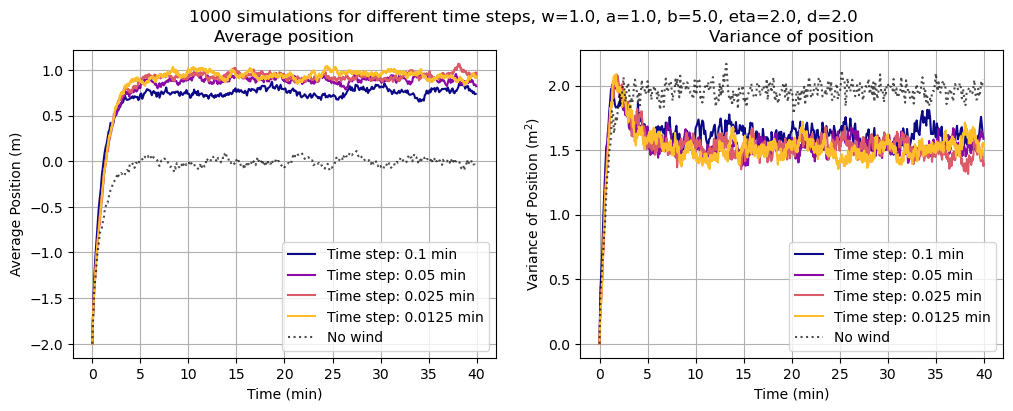

In [ ]:
#plot histogram from t=10 until end of positions for each time step
min=-3
max=3
n_bins=120
binsize=(max-min)/n_bins
t_stable=10

fig,ax=plt.subplots(figsize=(8, 4))
for it,t_step in enumerate(t_step_array):
    ax.hist(positions[it][:, int(t_stable/t_step):].flatten(), bins=n_bins, range=(min, max), density=True, alpha=0.5, edgecolor=plt.cm.plasma(it/3.5),color=plt.cm.plasma(it/3.5), label=f'Time step: {t_step} min')
ax.set_title(f'Histogram of positions from t={t_stable} min to end for {num_simulations} simulations')
ax.set_xlabel('Position (m)')
ax.set_ylabel(f'Frequency Density / binsize={binsize:.2f} m')
ax.legend()
ax.grid()
#fig.savefig('histogram.png')


#plot average position over time for each time step and variance of position over time for each time step
fig,ax=plt.subplots(1,2, figsize=(12, 4))
for it,t_step in enumerate(t_step_array):
    ax[0].plot(time_array[it], positions[it].mean(axis=0), c=plt.cm.plasma(it/3.5), label=f'Time step: {t_step} min')
    ax[1].plot(time_array[it], positions[it].var(axis=0), c=plt.cm.plasma(it/3.5), label=f'Time step: {t_step} min')
ax[0].plot(time_array[0], mean_positions_no_wind, c='k', label='No wind', linestyle=':',alpha=0.7)
ax[1].plot(time_array[0], var_positions_no_wind, c='k', label='No wind', linestyle=':',alpha=0.7)
ax[0].set_title(f'Average position')
ax[0].set_xlabel('Time (min)')
ax[0].set_ylabel('Average Position (m)')
ax[0].legend()
ax[0].grid()
ax[1].set_title(f'Variance of position')
ax[1].set_xlabel('Time (min)')
ax[1].set_ylabel('Variance of Position (m$^2$)')
ax[1].legend()
ax[1].grid()
fig.suptitle(f'{num_simulations} simulations for different time steps, w={w}, a={a}, b={b}, eta={eta}, d={d}')
#fig.savefig('average_variance.png')

## d) Summarize results and compare to with predictions

describe one insight, if prediction matches

The Langevin model for this system and for this set of parameters has a drift towards one side of the double well potential, which was also predicted and can be seen in the mean (fig.\ref)
The mean position over time was as expected and was landing in one valley of the potential - although not in the deepest spot of the potential, but depending on the wind term, a little more to the outer side.
The variance jumps up in the beginning, as the system has not found its place yet, where it then tumbles around its ensemble mean, through which the variance stabilizes. I came hereby to the insight, that the variance is \underline{always} smaller in the long run, than in the case without wind. This is because $Var=\langle (X-\langle X \rangle)^2 \rangle$ has its maximum, where $\langle X \rangle = 0$.
One more insight was, that the constant wind term could also be put in the potential term, through which the potential gets distorted to one side and the same model emerges.

The biggest insight I had during experimenting was, that I could not put the wind bias in the noise term, like in this piece of code:
\code
def brownian_movement(diffusion_coef, time_step,bias):
    return np.random.normal(bias, np.sqrt(2 * diffusion_coef * time_step))

def next_position(current_position, d,a,b,eta, t_step,bias):
    return current_position + brownian_movement(d,t_step,bias) + potential_force(current_position, a, b, eta)* t_step

This gave a time step dependent behaviour and costed me some time to understand.